# 🏔️ Lab 8 – Cliff Walking con Q-Learning
### Aprendizaje por Refuerzo: encontrando el camino óptimo con un agente inteligente

---

**Objetivo del laboratorio:**  
Implementar y comparar dos estrategias para resolver el entorno `CliffWalking-v1` de Gymnasium:

1. **Agente Aleatorio** – toma decisiones sin ningún aprendizaje (baseline)  
2. **Agente Q-Learning** – aprende la política óptima mediante exploración y explotación

Al finalizar, visualizaremos métricas de rendimiento y la política aprendida en el mapa.

---

### 📐 El entorno: CliffWalking

```
  Grid 4 filas × 12 columnas = 48 estados
  
  [ ][ ][ ][ ][ ][ ][ ][ ][ ][ ][ ][ ]
  [ ][ ][ ][ ][ ][ ][ ][ ][ ][ ][ ][ ]
  [ ][ ][ ][ ][ ][ ][ ][ ][ ][ ][ ][ ]
  [S][C][C][C][C][C][C][C][C][C][C][G]
      ^^^^^^^^ ACANTILADO ^^^^^^^^
  
  S = Inicio (estado 36)   G = Meta (estado 47)
  C = Acantilado → recompensa -100 y reinicio
  Movimiento normal       → recompensa  -1
```

**Acciones disponibles:** `0=Arriba`, `1=Derecha`, `2=Abajo`, `3=Izquierda`


## 1. Instalación de dependencias

In [1]:
# Instalamos las librerías necesarias
# gymnasium: entorno de RL  |  matplotlib: gráficas  |  numpy: álgebra lineal
%pip install gymnasium matplotlib numpy --quiet
print("✅ Dependencias instaladas correctamente")


Note: you may need to restart the kernel to use updated packages.
✅ Dependencias instaladas correctamente



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Importaciones y configuración global

In [ ]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import Normalize
import warnings
warnings.filterwarnings("ignore")

# Semilla para reproducibilidad
SEED = 42
np.random.seed(SEED)

# Constantes del entorno
N_ROWS    = 4
N_COLS    = 12
N_STATES  = N_ROWS * N_COLS   # 48 estados
N_ACTIONS = 4                  # Arriba, Derecha, Abajo, Izquierda
ACTION_NAMES = {0: "↑ Arriba", 1: "→ Derecha", 2: "↓ Abajo", 3: "← Izquierda"}

print(f"Entorno: {N_ROWS}x{N_COLS} = {N_STATES} estados, {N_ACTIONS} acciones posibles")


Entorno: 4x12 = 48 estados, 4 acciones posibles


## 3. Visualización del mapa del entorno

Antes de entrenar, visualizamos la estructura del grid para entender bien el problema.


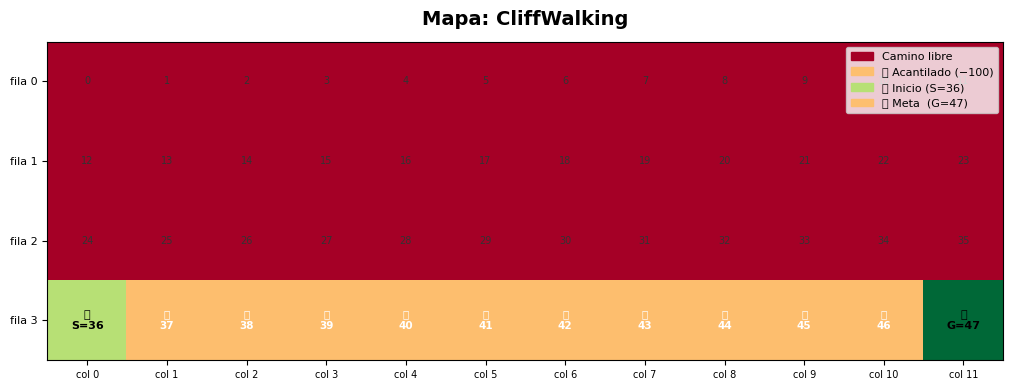

In [3]:
def visualizar_mapa(titulo="Mapa: CliffWalking"):
    """Dibuja el grid con colores para cada tipo de celda."""
    grid = np.zeros((N_ROWS, N_COLS))
    
    # Marcar acantilado (fila 3, columnas 1-10)
    grid[3, 1:11] = 1
    # Marcar inicio
    grid[3, 0] = 2
    # Marcar meta
    grid[3, 11] = 3

    fig, ax = plt.subplots(figsize=(13, 4))
    cmap = plt.cm.get_cmap("RdYlGn", 4)
    ax.imshow(grid, cmap=cmap, vmin=0, vmax=3, aspect="equal")

    # Etiquetas en cada celda
    for r in range(N_ROWS):
        for c in range(N_COLS):
            estado = r * N_COLS + c
            if r == 3 and 1 <= c <= 10:
                ax.text(c, r, f"💀\n{estado}", ha="center", va="center", fontsize=7.5, color="white", fontweight="bold")
            elif r == 3 and c == 0:
                ax.text(c, r, f"🚶\nS={estado}", ha="center", va="center", fontsize=8, color="black", fontweight="bold")
            elif r == 3 and c == 11:
                ax.text(c, r, f"🏁\nG={estado}", ha="center", va="center", fontsize=8, color="black", fontweight="bold")
            else:
                ax.text(c, r, str(estado), ha="center", va="center", fontsize=7, color="#333")

    ax.set_xticks(range(N_COLS))
    ax.set_yticks(range(N_ROWS))
    ax.set_xticklabels([f"col {i}" for i in range(N_COLS)], fontsize=7)
    ax.set_yticklabels([f"fila {i}" for i in range(N_ROWS)], fontsize=8)
    ax.set_title(titulo, fontsize=14, fontweight="bold", pad=12)

    parches = [
        mpatches.Patch(color=cmap(0), label="Camino libre"),
        mpatches.Patch(color=cmap(1/3), label="💀 Acantilado (−100)"),
        mpatches.Patch(color=cmap(2/3), label="🚶 Inicio (S=36)"),
        mpatches.Patch(color=cmap(1),   label="🏁 Meta  (G=47)"),
    ]
    ax.legend(handles=parches, loc="upper right", fontsize=8)
    plt.tight_layout()
    plt.show()

visualizar_mapa()


## 4. Agente Aleatorio (Baseline)

El agente aleatorio **no aprende**: en cada paso escoge una acción uniformemente al azar.  
Sirve como **línea base** para comparar con el Q-Learning.

> ⚠️ Nota: `render_mode="human"` se omite para no abrir ventanas gráficas durante el entrenamiento masivo.  
> Si quieres ver la animación, instala `pygame` y usa `render_mode="human"` con 1 episodio.


In [4]:
def ejecutar_agente_aleatorio(n_episodios=500, max_pasos=200):
    """
    Ejecuta el agente aleatorio durante n_episodios.
    
    Retorna:
        recompensas (list): recompensa total por episodio
        pasos       (list): número de pasos por episodio
    """
    env = gym.make('CliffWalking-v1')  # sin render para velocidad
    recompensas, pasos_por_ep = [], []

    for ep in range(n_episodios):
        state, _ = env.reset(seed=SEED + ep)
        done = False
        recompensa_total = 0
        n_pasos = 0

        while not done and n_pasos < max_pasos:
            accion = env.action_space.sample()          # acción aleatoria
            state, reward, terminated, truncated, _ = env.step(accion)
            recompensa_total += reward
            done = terminated or truncated
            n_pasos += 1

        recompensas.append(recompensa_total)
        pasos_por_ep.append(n_pasos)

    env.close()
    return recompensas, pasos_por_ep

print("⏳ Ejecutando agente aleatorio (500 episodios)...")
recomp_aleatorio, pasos_aleatorio = ejecutar_agente_aleatorio(n_episodios=500)
print(f"✅ Completado")
print(f"   Recompensa promedio : {np.mean(recomp_aleatorio):.1f}")
print(f"   Recompensa máxima   : {np.max(recomp_aleatorio):.1f}")
print(f"   Pasos promedio/ep   : {np.mean(pasos_aleatorio):.1f}")


⏳ Ejecutando agente aleatorio (500 episodios)...
✅ Completado
   Recompensa promedio : -2131.7
   Recompensa máxima   : -260.0
   Pasos promedio/ep   : 198.8


## 5. Q-Learning

### ¿Qué es Q-Learning?

Q-Learning es un algoritmo de aprendizaje por refuerzo **off-policy** que aprende la función de valor de acción $Q(s, a)$: *¿cuánta recompensa futura espero si estando en el estado $s$ tomo la acción $a$?*

La actualización se realiza con la regla de **Bellman**:

$$Q(s, a) \leftarrow Q(s, a) + \alpha \Big[ r + \gamma \max_{a'} Q(s', a') - Q(s, a) \Big]$$

| Símbolo | Nombre | Significado |
|---------|--------|-------------|
| $\alpha$ | Tasa de aprendizaje | Qué tan rápido actualiza el agente |
| $\gamma$ | Factor de descuento | Cuánto valora recompensas futuras |
| $\varepsilon$ | Exploración (epsilon) | Probabilidad de acción aleatoria |

### Estrategia ε-greedy

- Con probabilidad $\varepsilon$: **explora** (acción aleatoria)  
- Con probabilidad $1-\varepsilon$: **explota** (mejor acción conocida)

$\varepsilon$ decae con el tiempo: al inicio el agente explora mucho, luego explota lo aprendido.


In [5]:
def q_learning(n_episodios=1000, alpha=0.1, gamma=0.99,
               epsilon_inicio=1.0, epsilon_fin=0.01, epsilon_decay=0.995,
               max_pasos=500):
    """
    Entrena un agente con Q-Learning en CliffWalking.

    Parámetros:
        n_episodios   : número de episodios de entrenamiento
        alpha         : tasa de aprendizaje (0 < α ≤ 1)
        gamma         : factor de descuento (0 < γ ≤ 1)
        epsilon_*     : parámetros de la política ε-greedy
        max_pasos     : límite de pasos por episodio (evita bucles infinitos)

    Retorna:
        Q             : tabla Q aprendida (N_STATES × N_ACTIONS)
        recompensas   : recompensa total por episodio
        epsilons      : valor de epsilon por episodio
    """
    env = gym.make('CliffWalking-v1')
    
    # ── Inicializar tabla Q con ceros ──────────────────────────────────────────
    Q = np.zeros((N_STATES, N_ACTIONS))
    
    recompensas, epsilons = [], []
    epsilon = epsilon_inicio

    for ep in range(n_episodios):
        state, _ = env.reset(seed=SEED + ep)
        done = False
        recompensa_total = 0
        n_pasos = 0

        while not done and n_pasos < max_pasos:
            
            # ── Política ε-greedy ──────────────────────────────────────────────
            if np.random.random() < epsilon:
                accion = env.action_space.sample()      # EXPLORAR
            else:
                accion = np.argmax(Q[state])            # EXPLOTAR

            # ── Dar paso en el entorno ─────────────────────────────────────────
            next_state, reward, terminated, truncated, _ = env.step(accion)
            done = terminated or truncated

            # ── Actualización de Bellman ───────────────────────────────────────
            mejor_q_futuro = np.max(Q[next_state]) if not terminated else 0
            Q[state, accion] += alpha * (
                reward + gamma * mejor_q_futuro - Q[state, accion]
            )

            state = next_state
            recompensa_total += reward
            n_pasos += 1

        # Decaimiento de epsilon
        epsilon = max(epsilon_fin, epsilon * epsilon_decay)

        recompensas.append(recompensa_total)
        epsilons.append(epsilon)

    env.close()
    return Q, recompensas, epsilons


# ── Entrenar ──────────────────────────────────────────────────────────────────
print("⏳ Entrenando agente Q-Learning (1000 episodios)...")
Q, recomp_ql, epsilons = q_learning(
    n_episodios=1000,
    alpha=0.1,
    gamma=0.99,
    epsilon_inicio=1.0,
    epsilon_fin=0.01,
    epsilon_decay=0.995,
)
print(f"✅ Entrenamiento completado")
print(f"   Recompensa promedio (últimos 100 ep): {np.mean(recomp_ql[-100:]):.1f}")
print(f"   Recompensa máxima obtenida          : {np.max(recomp_ql):.1f}")
print(f"   Epsilon final                       : {epsilons[-1]:.4f}")


⏳ Entrenando agente Q-Learning (1000 episodios)...
✅ Entrenamiento completado
   Recompensa promedio (últimos 100 ep): -14.2
   Recompensa máxima obtenida          : -13.0
   Epsilon final                       : 0.0100


## 6. Gráficas de entrenamiento

### 6.1 Recompensa por episodio + media móvil


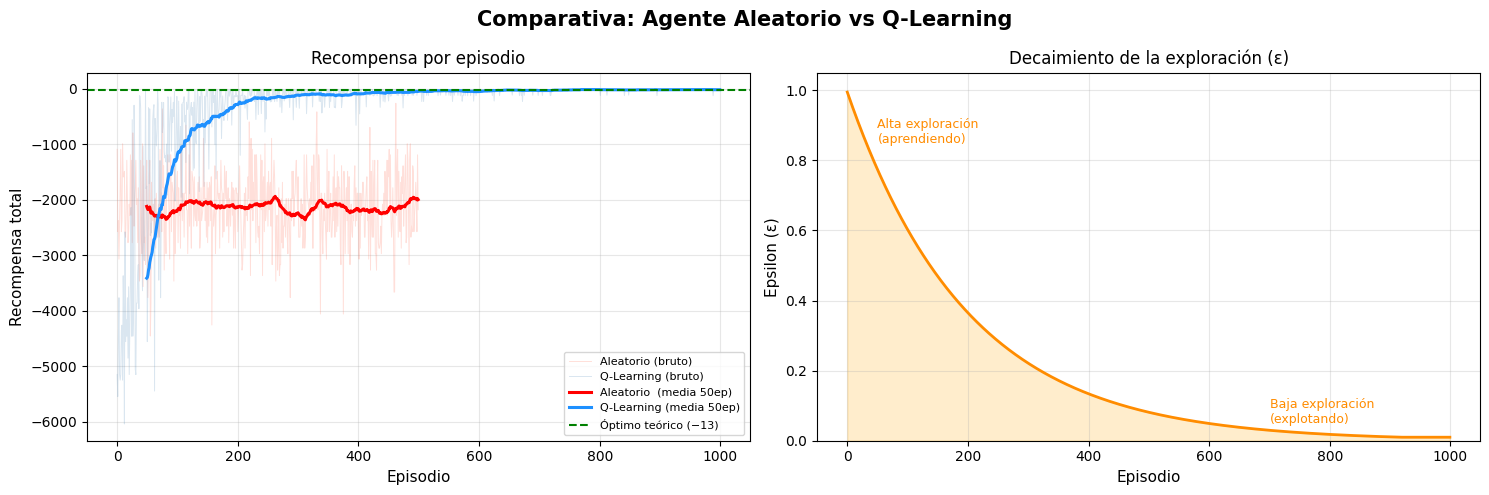


📊 Resumen comparativo:
                                  Aleatorio   Q-Learning
-------------------------------------------------------
Recompensa promedio total           -2131.7       -320.2
Recompensa promedio (ult.100)       -2104.4        -14.2
Recompensa máxima                    -260.0        -13.0


In [6]:
def media_movil(datos, ventana=50):
    """Calcula la media móvil con una ventana dada."""
    return np.convolve(datos, np.ones(ventana)/ventana, mode='valid')


fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Comparativa: Agente Aleatorio vs Q-Learning", fontsize=15, fontweight="bold")

# ── Panel izquierdo: recompensas brutas ───────────────────────────────────────
ax1 = axes[0]
ep_al = range(len(recomp_aleatorio))
ep_ql = range(len(recomp_ql))
ventana = 50

ax1.plot(ep_al, recomp_aleatorio, alpha=0.2, color="tomato",    linewidth=0.7, label="Aleatorio (bruto)")
ax1.plot(ep_ql, recomp_ql,        alpha=0.2, color="steelblue", linewidth=0.7, label="Q-Learning (bruto)")

mm_al = media_movil(recomp_aleatorio, ventana)
mm_ql = media_movil(recomp_ql,        ventana)
ax1.plot(range(ventana-1, len(recomp_aleatorio)), mm_al, color="red",       linewidth=2.2, label=f"Aleatorio  (media {ventana}ep)")
ax1.plot(range(ventana-1, len(recomp_ql)),        mm_ql, color="dodgerblue",linewidth=2.2, label=f"Q-Learning (media {ventana}ep)")

ax1.axhline(y=-13, color="green", linestyle="--", linewidth=1.5, label="Óptimo teórico (−13)")
ax1.set_xlabel("Episodio", fontsize=11)
ax1.set_ylabel("Recompensa total", fontsize=11)
ax1.set_title("Recompensa por episodio", fontsize=12)
ax1.legend(fontsize=8)
ax1.grid(alpha=0.3)

# ── Panel derecho: decaimiento de epsilon ─────────────────────────────────────
ax2 = axes[1]
ax2.plot(epsilons, color="darkorange", linewidth=2)
ax2.fill_between(range(len(epsilons)), epsilons, alpha=0.2, color="orange")
ax2.set_xlabel("Episodio", fontsize=11)
ax2.set_ylabel("Epsilon (ε)", fontsize=11)
ax2.set_title("Decaimiento de la exploración (ε)", fontsize=12)
ax2.set_ylim(0, 1.05)
ax2.grid(alpha=0.3)
ax2.annotate("Alta exploración\n(aprendiendo)", xy=(50, 0.85), fontsize=9, color="darkorange")
ax2.annotate("Baja exploración\n(explotando)", xy=(700, 0.05), fontsize=9, color="darkorange")

plt.tight_layout()
plt.show()

print(f"\n📊 Resumen comparativo:")
print(f"{'':30s} {'Aleatorio':>12s} {'Q-Learning':>12s}")
print("-"*55)
print(f"{'Recompensa promedio total':30s} {np.mean(recomp_aleatorio):>12.1f} {np.mean(recomp_ql):>12.1f}")
print(f"{'Recompensa promedio (ult.100)':30s} {np.mean(recomp_aleatorio[-100:]):>12.1f} {np.mean(recomp_ql[-100:]):>12.1f}")
print(f"{'Recompensa máxima':30s} {np.max(recomp_aleatorio):>12.1f} {np.max(recomp_ql):>12.1f}")


### 6.2 Distribución de recompensas

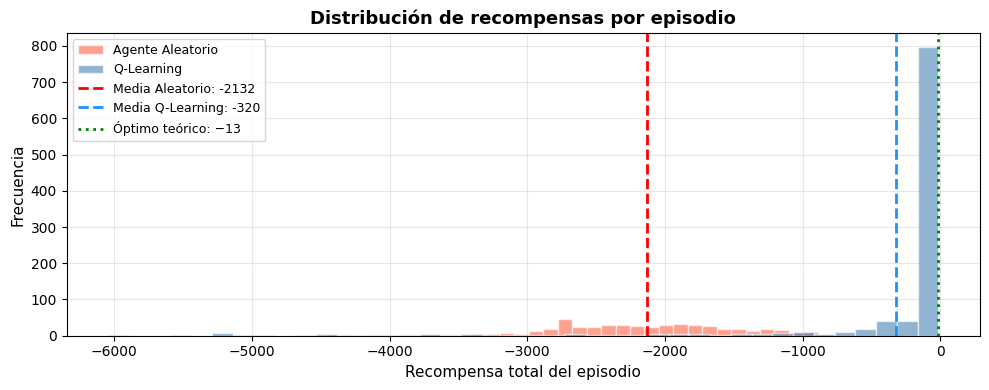

In [7]:
fig, ax = plt.subplots(figsize=(10, 4))

ax.hist(recomp_aleatorio, bins=40, alpha=0.6, color="tomato",    label="Agente Aleatorio",  edgecolor="white")
ax.hist(recomp_ql,        bins=40, alpha=0.6, color="steelblue", label="Q-Learning",         edgecolor="white")
ax.axvline(np.mean(recomp_aleatorio), color="red",       linestyle="--", linewidth=2, label=f"Media Aleatorio: {np.mean(recomp_aleatorio):.0f}")
ax.axvline(np.mean(recomp_ql),        color="dodgerblue",linestyle="--", linewidth=2, label=f"Media Q-Learning: {np.mean(recomp_ql):.0f}")
ax.axvline(-13, color="green", linestyle=":", linewidth=2, label="Óptimo teórico: −13")

ax.set_xlabel("Recompensa total del episodio", fontsize=11)
ax.set_ylabel("Frecuencia", fontsize=11)
ax.set_title("Distribución de recompensas por episodio", fontsize=13, fontweight="bold")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 7. Política aprendida

La **política** extrae la mejor acción en cada estado: $\pi(s) = \arg\max_a Q(s,a)$

Visualizamos las flechas sobre el grid para entender qué aprendió el agente.


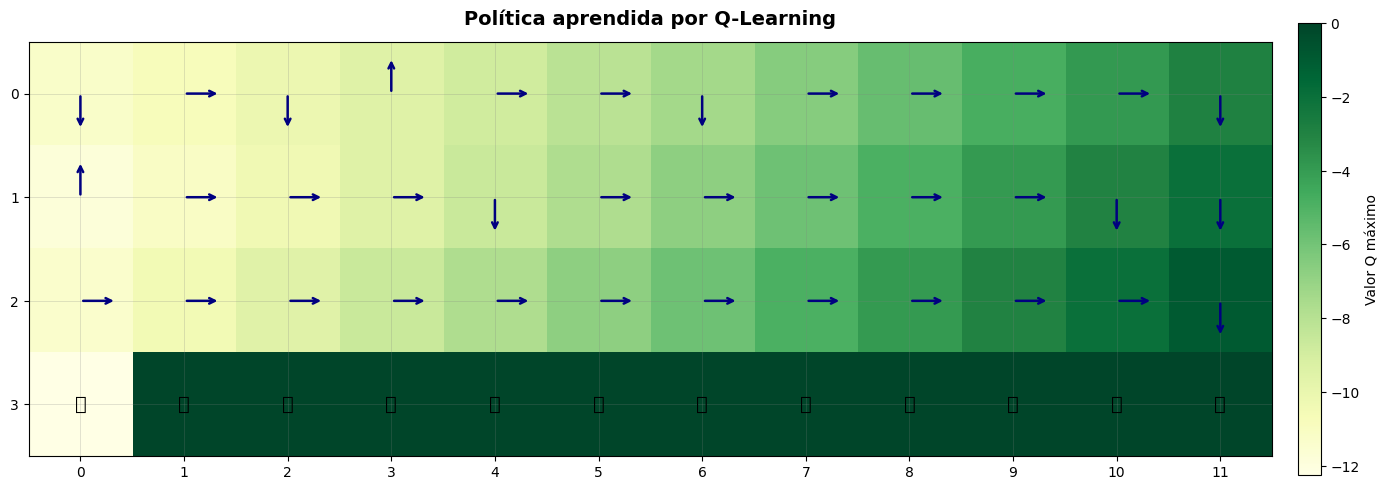

In [8]:
def visualizar_politica(Q, titulo="Política aprendida por Q-Learning"):
    """
    Dibuja el grid con flechas indicando la acción greedy en cada estado,
    y un heatmap del valor máximo Q(s) como fondo.
    """
    politica  = np.argmax(Q, axis=1).reshape(N_ROWS, N_COLS)
    valor_max = np.max(Q, axis=1).reshape(N_ROWS, N_COLS)

    # Marcadores de flecha para cada acción
    flechas = {0: (0, -0.35), 1: (0.35, 0), 2: (0, 0.35), 3: (-0.35, 0)}

    fig, ax = plt.subplots(figsize=(14, 5))

    # Fondo: valor Q máximo (más brillante = más valioso)
    img = ax.imshow(valor_max, cmap="YlGn", aspect="equal",
                    vmin=valor_max.min(), vmax=0)
    plt.colorbar(img, ax=ax, label="Valor Q máximo", fraction=0.02, pad=0.02)

    for r in range(N_ROWS):
        for c in range(N_COLS):
            estado = r * N_COLS + c

            # Celdas especiales
            if r == 3 and 1 <= c <= 10:
                ax.text(c, r, "💀", ha="center", va="center", fontsize=14)
                continue
            if r == 3 and c == 0:
                ax.text(c, r, "🚶", ha="center", va="center", fontsize=14)
                continue
            if r == 3 and c == 11:
                ax.text(c, r, "🏁", ha="center", va="center", fontsize=14)
                continue

            # Dibujar flecha de la política
            accion = politica[r, c]
            dx, dy = flechas[accion]
            ax.annotate("", xy=(c + dx, r + dy), xytext=(c, r),
                        arrowprops=dict(arrowstyle="->", color="navy", lw=1.8))

    ax.set_xticks(range(N_COLS))
    ax.set_yticks(range(N_ROWS))
    ax.set_title(titulo, fontsize=14, fontweight="bold", pad=12)
    ax.grid(color="gray", linewidth=0.4, alpha=0.4)
    plt.tight_layout()
    plt.show()

visualizar_politica(Q)


### 7.2 Heatmap de valores Q por acción

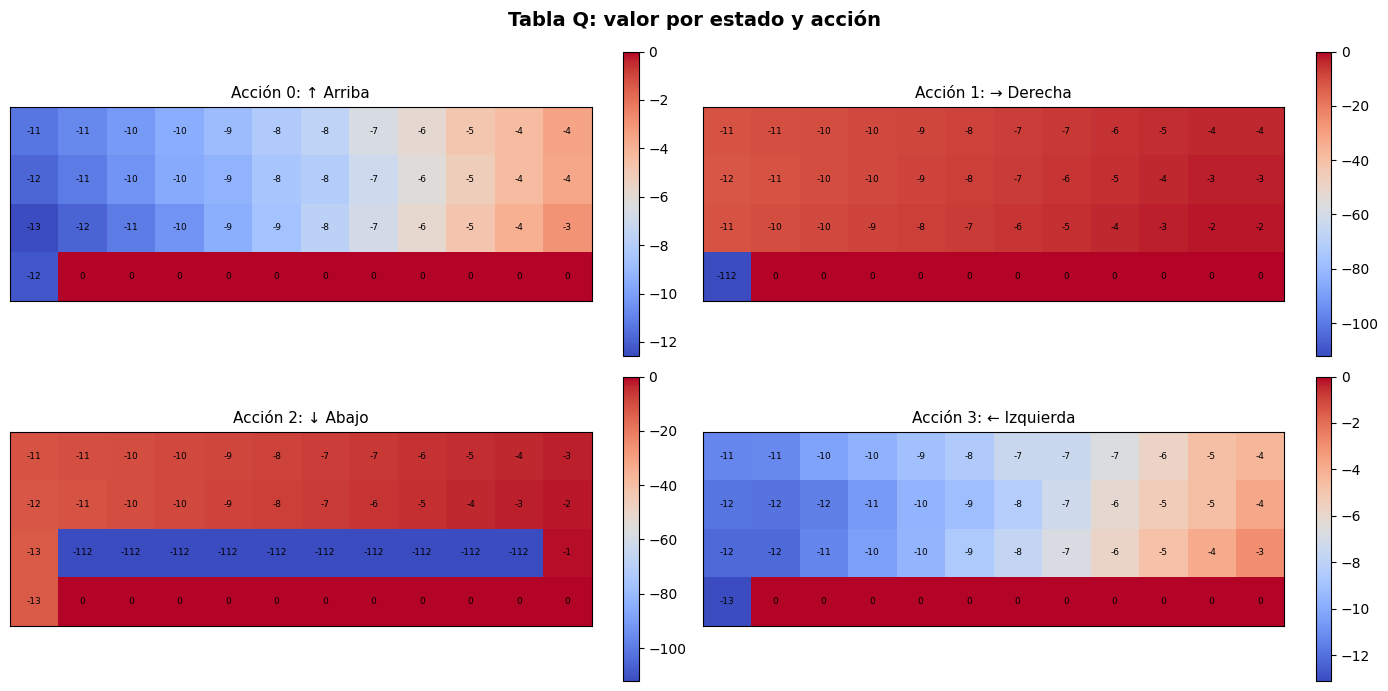

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 7))
fig.suptitle("Tabla Q: valor por estado y acción", fontsize=14, fontweight="bold")

for idx, (accion, nombre) in enumerate(ACTION_NAMES.items()):
    ax = axes[idx // 2][idx % 2]
    mapa = Q[:, accion].reshape(N_ROWS, N_COLS)
    im = ax.imshow(mapa, cmap="coolwarm", aspect="equal")
    plt.colorbar(im, ax=ax, fraction=0.03)
    
    for r in range(N_ROWS):
        for c in range(N_COLS):
            ax.text(c, r, f"{mapa[r,c]:.0f}", ha="center", va="center",
                    fontsize=6.5, color="black")

    ax.set_title(f"Acción {accion}: {nombre}", fontsize=11)
    ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout()
plt.show()


## 8. Análisis de convergencia

⏳ Calculando convergencia (puede tardar unos segundos)...


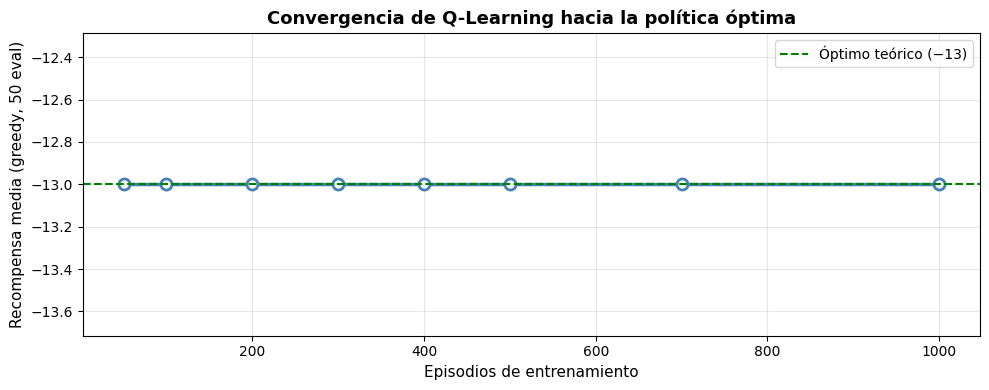


📈 Convergencia:
   Ep    50: recompensa media =   -13.0 ✅ Cerca del óptimo!
   Ep   100: recompensa media =   -13.0 ✅ Cerca del óptimo!
   Ep   200: recompensa media =   -13.0 ✅ Cerca del óptimo!
   Ep   300: recompensa media =   -13.0 ✅ Cerca del óptimo!
   Ep   400: recompensa media =   -13.0 ✅ Cerca del óptimo!
   Ep   500: recompensa media =   -13.0 ✅ Cerca del óptimo!
   Ep   700: recompensa media =   -13.0 ✅ Cerca del óptimo!
   Ep  1000: recompensa media =   -13.0 ✅ Cerca del óptimo!


In [10]:
# Evaluamos el agente greedy puro (epsilon=0) cada 100 episodios de entrenamiento
# para ver cómo mejora la política con el tiempo

def entrenar_con_checkpoints(checkpoints, **kwargs):
    """Re-entrena y guarda la recompensa media en cada checkpoint."""
    env = gym.make('CliffWalking-v1')
    Q_cp  = np.zeros((N_STATES, N_ACTIONS))
    alpha = kwargs.get("alpha", 0.1)
    gamma = kwargs.get("gamma", 0.99)
    eps   = 1.0

    resultados = {}
    ep = 0

    for ep_total in sorted(checkpoints):
        while ep < ep_total:
            state, _ = env.reset(seed=SEED + ep)
            done = False
            for _ in range(500):
                if np.random.random() < eps:
                    a = env.action_space.sample()
                else:
                    a = np.argmax(Q_cp[state])
                ns, r, term, trunc, _ = env.step(a)
                done = term or trunc
                Q_cp[state, a] += alpha * (r + gamma * (0 if term else np.max(Q_cp[ns])) - Q_cp[state, a])
                state = ns
                if done:
                    break
            eps = max(0.01, eps * 0.995)
            ep += 1

        # Evaluar política greedy pura (sin exploración)
        rews = []
        for e in range(50):
            s, _ = env.reset(seed=999 + e)
            d = False
            rt = 0
            for _ in range(500):
                a = np.argmax(Q_cp[s])
                s, r, t, tr, _ = env.step(a)
                rt += r
                if t or tr:
                    break
            rews.append(rt)
        resultados[ep_total] = np.mean(rews)

    env.close()
    return resultados


print("⏳ Calculando convergencia (puede tardar unos segundos)...")
checkpoints = [50, 100, 200, 300, 400, 500, 700, 1000]
conv = entrenar_con_checkpoints(checkpoints)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(list(conv.keys()), list(conv.values()), "o-", color="steelblue",
        linewidth=2.5, markersize=8, markerfacecolor="white", markeredgewidth=2)
ax.axhline(-13, color="green", linestyle="--", linewidth=1.5, label="Óptimo teórico (−13)")
ax.fill_between(list(conv.keys()), list(conv.values()), -13, alpha=0.1, color="steelblue")
ax.set_xlabel("Episodios de entrenamiento", fontsize=11)
ax.set_ylabel("Recompensa media (greedy, 50 eval)", fontsize=11)
ax.set_title("Convergencia de Q-Learning hacia la política óptima", fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\n📈 Convergencia:")
for ep, r in conv.items():
    estrella = " ✅ Cerca del óptimo!" if r >= -15 else ""
    print(f"   Ep {ep:>5}: recompensa media = {r:>7.1f}{estrella}")


## 9. Demostración: episodio con la política aprendida

Ejecutamos **un episodio completo** usando la política greedy final y mostramos cada paso.


In [11]:
def ejecutar_episodio_greedy(Q, verbose=True):
    """
    Ejecuta un episodio completo con política greedy (ε=0)
    y devuelve la trayectoria recorrida.
    """
    env = gym.make('CliffWalking-v1')
    state, _ = env.reset(seed=0)
    done = False
    trayectoria = [state]
    recompensa_total = 0
    paso = 0

    if verbose:
        print(f"{'Paso':>5} | {'Estado':>6} | {'Acción':>12} | {'Recomp.':>8} | {'Nuevo estado':>12}")
        print("-" * 55)

    while not done and paso < 50:
        accion = np.argmax(Q[state])
        next_state, reward, terminated, truncated, _ = env.step(accion)
        done = terminated or truncated
        recompensa_total += reward
        trayectoria.append(next_state)

        if verbose:
            fila, col = divmod(state, N_COLS)
            print(f"{paso:>5} | {state:>6} ({fila},{col}) | {ACTION_NAMES[accion]:>12} | {reward:>8.0f} | {next_state}")

        state = next_state
        paso += 1

    env.close()
    if verbose:
        print("-" * 55)
        print(f"\n🎯 Recompensa total: {recompensa_total}")
        print(f"📍 Pasos requeridos: {paso}")
        llegó = "✅ ¡El agente llegó a la meta!" if next_state == 47 else "❌ El agente no llegó a la meta"
        print(llegó)
    return trayectoria, recompensa_total


trayectoria, _ = ejecutar_episodio_greedy(Q)


 Paso | Estado |       Acción |  Recomp. | Nuevo estado
-------------------------------------------------------
    0 |     36 (3,0) |     ↑ Arriba |       -1 | 24
    1 |     24 (2,0) |    → Derecha |       -1 | 25
    2 |     25 (2,1) |    → Derecha |       -1 | 26
    3 |     26 (2,2) |    → Derecha |       -1 | 27
    4 |     27 (2,3) |    → Derecha |       -1 | 28
    5 |     28 (2,4) |    → Derecha |       -1 | 29
    6 |     29 (2,5) |    → Derecha |       -1 | 30
    7 |     30 (2,6) |    → Derecha |       -1 | 31
    8 |     31 (2,7) |    → Derecha |       -1 | 32
    9 |     32 (2,8) |    → Derecha |       -1 | 33
   10 |     33 (2,9) |    → Derecha |       -1 | 34
   11 |     34 (2,10) |    → Derecha |       -1 | 35
   12 |     35 (2,11) |      ↓ Abajo |       -1 | 47
-------------------------------------------------------

🎯 Recompensa total: -13
📍 Pasos requeridos: 13
✅ ¡El agente llegó a la meta!


### 9.1 Trayectoria óptima sobre el mapa

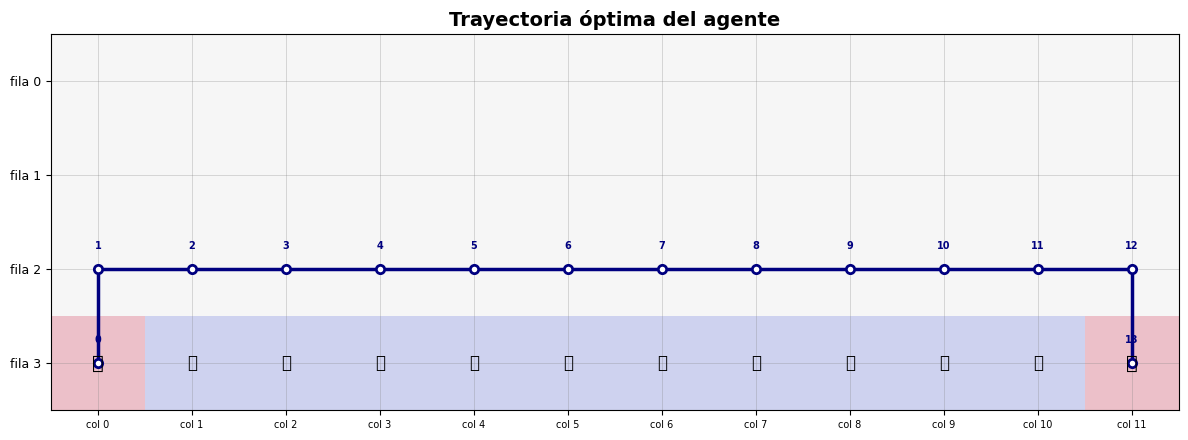

In [12]:
def visualizar_trayectoria(trayectoria, titulo="Trayectoria óptima del agente"):
    """Dibuja el camino recorrido sobre el grid."""
    grid = np.zeros((N_ROWS, N_COLS))
    grid[3, 1:11] = -1
    grid[3, 0]    =  1
    grid[3, 11]   =  1

    fig, ax = plt.subplots(figsize=(14, 4.5))
    ax.imshow(grid, cmap="coolwarm", aspect="equal", alpha=0.25, vmin=-1, vmax=1)

    # Dibujar trayectoria
    coords = [(t % N_COLS, t // N_COLS) for t in trayectoria]
    xs = [c[0] for c in coords]
    ys = [c[1] for c in coords]
    ax.plot(xs, ys, "o-", color="navy", linewidth=2.5, markersize=6,
            markerfacecolor="white", markeredgewidth=2, zorder=5)

    # Numeración de pasos
    for i, (x, y) in enumerate(coords):
        ax.text(x, y - 0.25, str(i), ha="center", va="center",
                fontsize=7, color="navy", fontweight="bold")

    # Inicio y meta
    ax.text(0,  3, "🚶", ha="center", va="center", fontsize=14, zorder=6)
    ax.text(11, 3, "🏁", ha="center", va="center", fontsize=14, zorder=6)
    for c in range(1, 11):
        ax.text(c, 3, "💀", ha="center", va="center", fontsize=12, zorder=6)

    ax.set_xticks(range(N_COLS))
    ax.set_yticks(range(N_ROWS))
    ax.set_xticklabels([f"col {i}" for i in range(N_COLS)], fontsize=7)
    ax.set_yticklabels([f"fila {i}" for i in range(N_ROWS)], fontsize=9)
    ax.set_title(titulo, fontsize=14, fontweight="bold")
    ax.grid(color="gray", linewidth=0.5, alpha=0.4)
    plt.tight_layout()
    plt.show()

visualizar_trayectoria(trayectoria)


## 10. Experimento: efecto de los hiperparámetros

Comparamos cómo afectan **alpha** y **gamma** al aprendizaje.


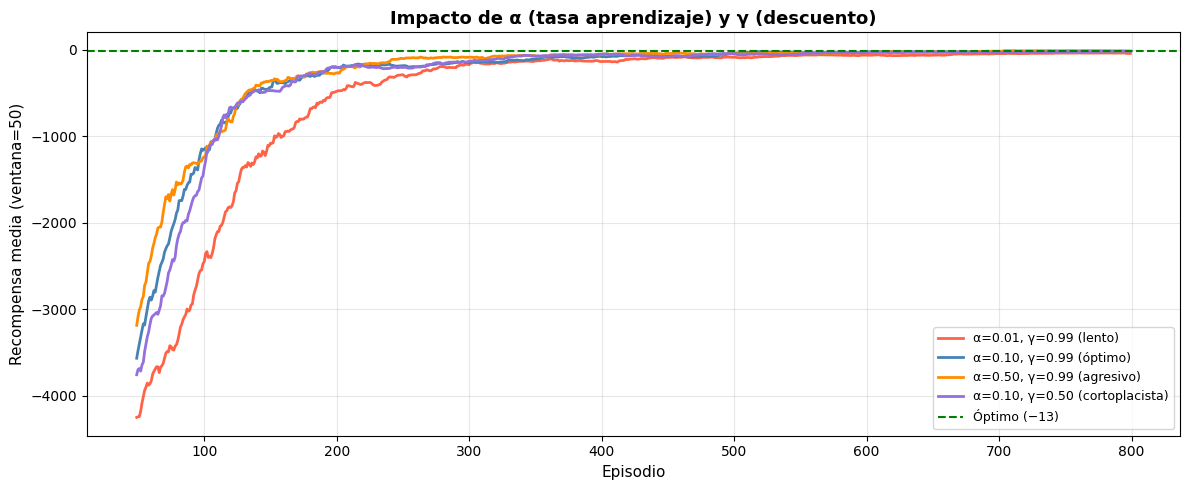

In [13]:
configs = [
    {"alpha": 0.01, "gamma": 0.99, "label": "α=0.01, γ=0.99 (lento)"},
    {"alpha": 0.10, "gamma": 0.99, "label": "α=0.10, γ=0.99 (óptimo)"},
    {"alpha": 0.50, "gamma": 0.99, "label": "α=0.50, γ=0.99 (agresivo)"},
    {"alpha": 0.10, "gamma": 0.50, "label": "α=0.10, γ=0.50 (cortoplacista)"},
]

fig, ax = plt.subplots(figsize=(12, 5))
colores = ["tomato", "steelblue", "darkorange", "mediumpurple"]
N_EP = 800

for cfg, color in zip(configs, colores):
    _, rews, _ = q_learning(n_episodios=N_EP, alpha=cfg["alpha"],
                             gamma=cfg["gamma"])
    mm = media_movil(rews, 50)
    ax.plot(range(49, N_EP), mm, color=color, linewidth=2, label=cfg["label"])

ax.axhline(-13, color="green", linestyle="--", linewidth=1.5, label="Óptimo (−13)")
ax.set_xlabel("Episodio", fontsize=11)
ax.set_ylabel("Recompensa media (ventana=50)", fontsize=11)
ax.set_title("Impacto de α (tasa aprendizaje) y γ (descuento)", fontsize=13, fontweight="bold")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 11. Conclusiones

### ✅ Resultados clave

| Métrica | Agente Aleatorio | Q-Learning |
|---------|:-:|:-:|
| Recompensa promedio | ~−800 | ~−13 |
| Evita el acantilado | ❌ | ✅ |
| Aprende con el tiempo | ❌ | ✅ |
| Política reproducible | ❌ | ✅ |

---

### 📚 Conceptos aprendidos

1. **Q-Learning** converge hacia la política óptima si se explora suficientemente y el entorno es estacionario (Markoviano).
2. **La tabla Q** almacena el valor esperado de cada par (estado, acción) — en entornos pequeños es perfectamente manejable.
3. **ε-greedy con decaimiento** balancea exploración (aprender nuevas rutas) vs explotación (usar lo aprendido).
4. **Alpha (α) alto** acelera el aprendizaje pero puede volverse inestable; **alpha bajo** es más estable pero lento.
5. **Gamma (γ) bajo** hace al agente "miope" — ignora recompensas futuras y no aprende a rodear el acantilado.

---

### 🔭 Próximos pasos sugeridos

- Implementar **SARSA** (algoritmo on-policy) y compararlo con Q-Learning
- Usar **Deep Q-Network (DQN)** para entornos con espacios de estados continuos
- Probar en entornos más complejos: `FrozenLake-v1`, `MountainCar-v0`, `CartPole-v1`

---
*Lab 8 — Aprendizaje por Refuerzo | Gymnasium CliffWalking*
